# Genetic Algorithm - Minimizing f(n) = -n^2 + 4n with Real-Valued Encoding


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Encoding scheme - 5-bit string maps to a real number in [0,4]

In [2]:
n_min, n_max, L = 0, 4, 5

def decode(bitstring):
    decimal_value = int(bitstring, 2)
    return n_min + (n_max - n_min) / (2**L - 1) * decimal_value

print("11010 ->", decode("11010"))
print("00000 ->", decode("00000"))
print("11111 ->", decode("11111"))

11010 -> 3.354838709677419
00000 -> 0.0
11111 -> 4.0


### Initial population and fitness, f(n) = -n^2 + 4n

In [3]:
population = ["10110", "01101", "11001", "00111"]

def fitness(n):
    return -n**2 + 4*n

decoded = [decode(s) for s in population]
fit = [fitness(n) for n in decoded]
gen1 = pd.DataFrame({"string": population, "decoded n": [round(x, 4) for x in decoded],
                      "f(n)=-n^2+4n": [round(x, 4) for x in fit]})
print(gen1)

total_fit = sum(fit)
avg_fit = total_fit / len(fit)
max_fit = max(fit)
print("Total fitness:", round(total_fit, 4), " Average:", round(avg_fit, 4), " Max:", round(max_fit, 4))

  string  decoded n  f(n)=-n^2+4n
0  10110     2.8387        3.2966
1  01101     1.6774        3.8959
2  11001     3.2258        2.4974
3  00111     0.9032        2.7971
Total fitness: 12.487  Average: 3.1217  Max: 3.8959


### Selection probabilities and cumulative probabilities for minimization

For a minimization problem, smaller objective values should have higher selection probability. We therefore use the standard shifted fitness transformation $F_i=f_{max}-f_i$.


In [4]:
# Convert the minimization objective into a selection fitness
f_max = max(fit)
selection_fitness = [f_max - f for f in fit]
total_selection_fitness = sum(selection_fitness)

if total_selection_fitness == 0:
    probs = [1 / len(population)] * len(population)
else:
    probs = [F / total_selection_fitness for F in selection_fitness]

cumulative = []
running = 0
for p in probs:
    running += p
    cumulative.append(running)

gen1["selection fitness"] = [round(F, 4) for F in selection_fitness]
gen1["probability"] = [round(p, 4) for p in probs]
gen1["cumulative"] = [round(c, 4) for c in cumulative]
print(gen1)
print("Sum of selection fitness:", round(total_selection_fitness, 4))
print("Sum of probabilities:", round(sum(probs), 4))


  string  decoded n  f(n)=-n^2+4n  selection fitness  probability  cumulative
0  10110     2.8387        3.2966             0.5994       0.1935      0.1935
1  01101     1.6774        3.8959             0.0000       0.0000      0.1935
2  11001     3.2258        2.4974             1.3985       0.4516      0.6452
3  00111     0.9032        2.7971             1.0989       0.3548      1.0000
Sum of selection fitness: 3.0968
Sum of probabilities: 1.0


### Roulette wheel selection using the given random numbers


In [5]:
given_randoms = [0.1, 0.3, 0.6, 0.85]
selected_indices = []
for r in given_randoms:
    for i, c in enumerate(cumulative):
        if r <= c:
            selected_indices.append(i)
            break

for r, idx in zip(given_randoms, selected_indices):
    print(f"r = {r}  falls in the range for individual {idx+1} ({population[idx]})")

mating_pool = [population[i] for i in selected_indices]
print("Mating pool:", mating_pool)


r = 0.1  falls in the range for individual 1 (10110)
r = 0.3  falls in the range for individual 3 (11001)
r = 0.6  falls in the range for individual 3 (11001)
r = 0.85  falls in the range for individual 4 (00111)
Mating pool: ['10110', '11001', '11001', '00111']


### Single-point crossover at the 3rd digit, as specified in the question

For a 5-bit chromosome, cutting after bit 3 leaves the complete chromosome on each side of the cut; therefore crossover produces the same parents as offspring.


In [6]:
crossover_point = 3

def crossover(parent1, parent2, point):
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

offspring = []
for i in range(0, len(mating_pool), 2):
    p1, p2 = mating_pool[i], mating_pool[i + 1]
    c1, c2 = crossover(p1, p2, crossover_point)
    print(f"Parents: {p1} , {p2}  ->  cut after bit {crossover_point}  ->  offspring: {c1} , {c2}")
    offspring.extend([c1, c2])

print("Population after crossover:", offspring)


Parents: 10110 , 11001  ->  cut after bit 3  ->  offspring: 10101 , 11010
Parents: 11001 , 00111  ->  cut after bit 3  ->  offspring: 11011 , 00101
Population after crossover: ['10101', '11010', '11011', '00101']


### Evaluate the new generation


In [7]:
new_decoded = [decode(s) for s in offspring]
new_fit = [fitness(n) for n in new_decoded]
gen2 = pd.DataFrame({"string": offspring, "decoded n": [round(x, 4) for x in new_decoded],
                      "f(n)=-n^2+4n": [round(x, 4) for x in new_fit]})
print(gen2)

new_total = sum(new_fit)
new_avg = new_total / len(new_fit)
new_min = min(new_fit)
best_index = new_fit.index(new_min)
print("Generation 1 -> Generation 2")
print("Average objective:", round(avg_fit, 4), "->", round(new_avg, 4))
print("Minimum objective:", round(min(fit), 4), "->", round(new_min, 4))
print("Best chromosome in generation 2:", offspring[best_index])
print("Best decoded n:", round(new_decoded[best_index], 4))
print("Best objective:", round(new_min, 4))


  string  decoded n  f(n)=-n^2+4n
0  10101     2.7097        3.4964
1  11010     3.3548        2.1644
2  11011     3.4839        1.7981
3  00101     0.6452        2.1644
Generation 1 -> Generation 2
Average objective: 3.1217 -> 2.4058
Minimum objective: 2.4974 -> 1.7981
Best chromosome in generation 2: 11011
Best decoded n: 3.4839
Best objective: 1.7981


### Plot the objective function with both generations marked


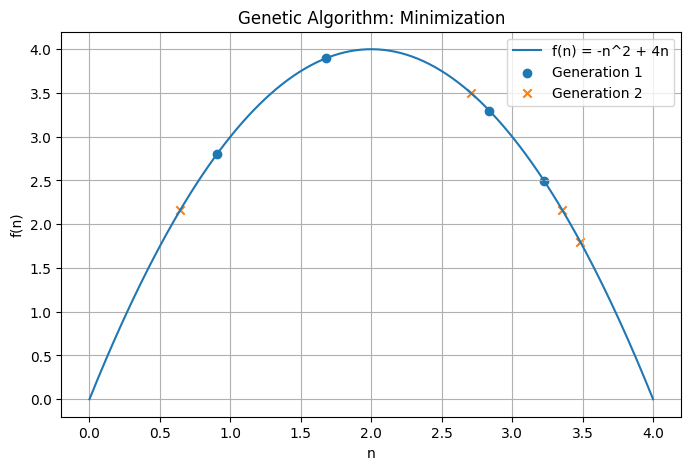

In [8]:
n_range = np.linspace(0, 4, 200)
f_range = [fitness(n) for n in n_range]

plt.figure(figsize=(8, 5))
plt.plot(n_range, f_range, label="f(n) = -n^2 + 4n")
plt.scatter(decoded, fit, label="Generation 1")
plt.scatter(new_decoded, new_fit, marker="x", label="Generation 2")
plt.xlabel("n")
plt.ylabel("f(n)")
plt.title("Genetic Algorithm: Minimization")
plt.legend()
plt.grid(True)
plt.show()


### Mutation step

The question specifies the four random numbers for roulette-wheel selection and the crossover point, but it does not specify a mutation probability or a mutation random number. Therefore no arbitrary mutation is introduced. The generation after the specified crossover is used as the final generation for this numerical problem.


In [9]:
print("Mutation: not applied because no mutation probability/random number is provided in the question.")


Mutation: not applied because no mutation probability/random number is provided in the question.


### Analytical verification of the minimization

$$f(n)=-n^2+4n=-(n-2)^2+4$$

On the closed interval $0\le n\le4$, the minimum occurs at an endpoint:
- $n=0$: $f(0)=0$
- $n=4$: $f(4)=0$

Thus the global minimum is $f(n)=0$ at $n=0$ or $n=4$. The given initial population does not contain either endpoint, so the best objective value in the given population/generation is the minimum value found by the generated population.

If the question literally uses $0<n<4$, the endpoints are excluded, so there is no attained minimum; the infimum is 0 as $n\to0^+$ or $n\to4^-$.


In [10]:
x_star_1, x_star_2 = 0, 4
print("Analytical endpoint minima:")
print("n = 0, f(n) =", fitness(0))
print("n = 4, f(n) =", fitness(4))
print("Best value found in generation 2:", round(new_min, 4))


Analytical endpoint minima:
n = 0, f(n) = 0
n = 4, f(n) = 0
Best value found in generation 2: 1.7981


### Q2 final result

The specified roulette-wheel selection (using minimization fitness), crossover at the 3rd digit, and the given random numbers produce the completed second generation. Mutation is not invented because its required parameter is absent from the question.
